In [1]:
import numpy as np
import matplotlib.pyplot as plt

import base
import matrix
import tsp 

In [2]:
berlinCoo = np.loadtxt('berlin52.tsp', skiprows=6, max_rows = 52, dtype=float)
#print(berlinCoo)
berlinPoints = np.linspace(0, 51, 52).astype(int)
#print(berlinPoints)

berlinOptTour = np.loadtxt('berlin52.opt.tour', dtype = int, skiprows = 4, max_rows = 52)
for i in range(len(berlinOptTour)):
    berlinOptTour[i] = berlinOptTour[i]-1
#print(berlinOptTour)

distancesBerlin = np.zeros((52, 52))
for i in range(52):
    for j in range(52):
        distancesBerlin[i, j] = np.sqrt((berlinCoo[i, 1] - berlinCoo[j, 1])**2 + (berlinCoo[i, 2] - berlinCoo[j, 2])**2)
#print(distancesBerlin)

pragueCoo = np.loadtxt('pr76.tsp', skiprows=6, max_rows = 76, dtype=float)
#print(pragueCoo)
praguePoints = np.linspace(0, 75, 76).astype(int)
#print(praguePoints)

linCoo = np.loadtxt('lin105.tsp', skiprows=6, max_rows = 105, dtype=float)
#print(pragueCoo)
linPoints = np.linspace(0, 104, 105).astype(int)
#print(praguePoints)

pragueOptTour = np.loadtxt('pr76.opt.tour', dtype = int, skiprows = 5, max_rows = 76)
for i in range(len(pragueOptTour)):
    pragueOptTour[i] = pragueOptTour[i]-1
#print(pragueOptTour)

linOptTour = np.loadtxt('lin105.opt.tour', dtype = int, skiprows = 5, max_rows = 105)
for i in range(len(linOptTour)):
    linOptTour[i] = linOptTour[i]-1
#print(linOptTour)

distancesPrague = np.zeros((76, 76))
for i in range(76):
    for j in range(76):
        distancesPrague[i, j] = np.sqrt((pragueCoo[i, 1] - pragueCoo[j, 1])**2 + (pragueCoo[i, 2] - pragueCoo[j, 2])**2)
#print(distancesPrague)

distancesLin = np.zeros((105, 105))
for i in range(105):
    for j in range(105):
        distancesLin[i, j] = np.sqrt((linCoo[i, 1] - linCoo[j, 1])**2 + (linCoo[i, 2] - linCoo[j, 2])**2)
#print(distancesLin)

optWeightBerlin = base.totalTravelDist(berlinOptTour, distancesBerlin, loop=True)
optWeightPrague = base.totalTravelDist(pragueOptTour, distancesPrague, loop=True)
optWeightLin = base.totalTravelDist(linOptTour, distancesLin, loop=True)

In [3]:
weightsBerlin, pathsBerlin, tempsBerlin = base.traveling_MC_constDist_history_adaptiveTemp(berlinPoints, distancesBerlin, 20000)
weightsPrague, pathsPrague, tempsPrague = base.traveling_MC_constDist_history_adaptiveTemp(praguePoints, distancesPrague, 20000)
weightsLin, pathsLin, tempsLin = base.traveling_MC_constDist_history_adaptiveTemp(linPoints, distancesLin, 20000)

/home/user/Physik_Bonn/CompPhys/project/base.py:243: RuntimeWarning: overflow encountered in exp
  if np.random.uniform(low=0, high=1) < np.exp((pathWeights[i]-new_cost)/temps[i]):


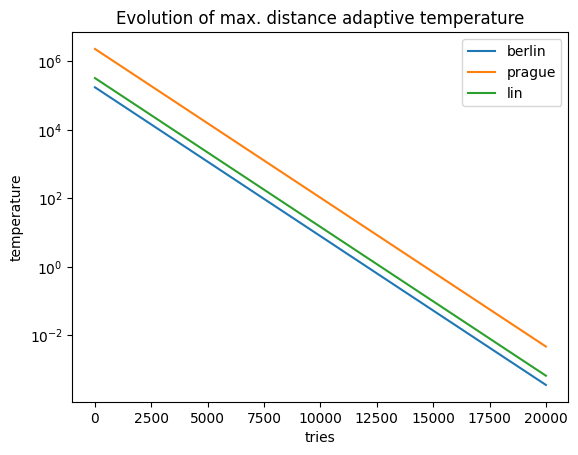

In [4]:
plt.plot(np.linspace(0, 20000, 20001), tempsBerlin, label = 'berlin')
plt.plot(np.linspace(0, 20000, 20001), tempsPrague, label = 'prague')
plt.plot(np.linspace(0, 20000, 20001), tempsLin, label = 'lin')
plt.xlabel('tries')
plt.ylabel('temperature')
plt.title('Evolution of max. distance adaptive temperature')
plt.yscale('log')

plt.legend()
plt.show()

In [23]:
weightsBerlin_reuse, pathsBerlin_reuse, tempsBerlin_reuse = base.traveling_MC_reuse_constDist_history_adaptiveTemp(berlinPoints, distancesBerlin, 5, 20000, temp_reuse=200)
weightsPrague_reuse, tempsPrague_reuse = base.traveling_MC_reuse_constDist_history_adaptiveTemp_noPaths(praguePoints, distancesPrague, 5, 40000, temp_reuse=4000)
weightsLin_reuse, tempsLin_reuse = base.traveling_MC_reuse_constDist_history_adaptiveTemp_noPaths(linPoints, distancesLin, 5, 60000, temp_reuse=100)

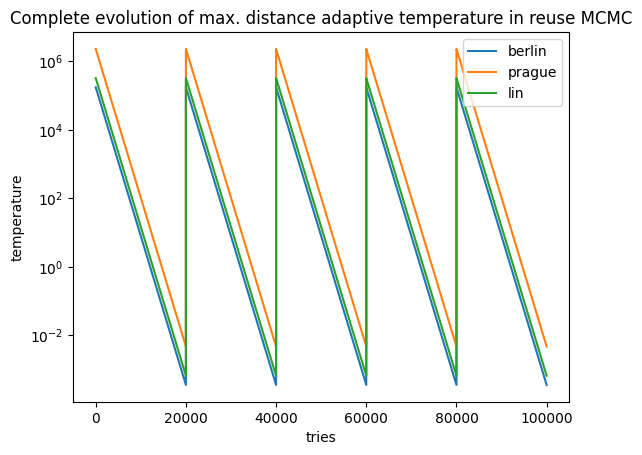

In [6]:
plt.plot(np.linspace(0, 100004, 100005), tempsBerlin_reuse, label = 'berlin')
plt.plot(np.linspace(0, 100004, 100005), tempsPrague_reuse, label = 'prague')
plt.plot(np.linspace(0, 100004, 100005), tempsLin_reuse, label = 'lin')
plt.xlabel('tries')
plt.ylabel('temperature')
plt.title('Complete evolution of max. distance adaptive temperature in reuse MCMC')
plt.yscale('log')

plt.legend()
plt.show()

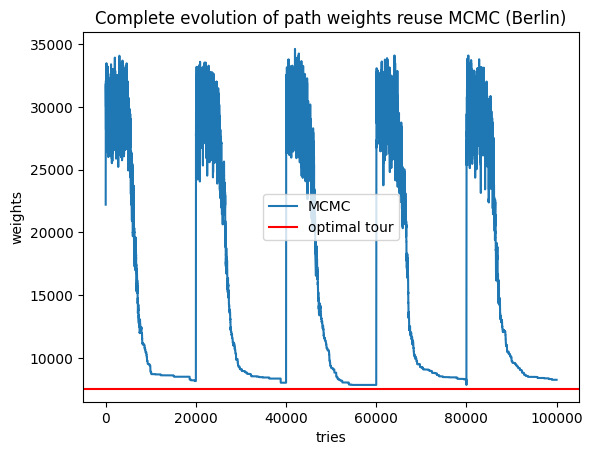

In [7]:
plt.plot(np.linspace(0, 100004, 100005), weightsBerlin_reuse, label = 'MCMC')
#plt.plot(np.linspace(0, 100004, 100005), weightsPrague_reuse, label = 'prague')
#plt.plot(np.linspace(0, 100004, 100005), weightsLin_reuse, label = 'lin')
plt.xlabel('tries')
plt.ylabel('weights')
plt.title('Complete evolution of path weights reuse MCMC (Berlin)')
#plt.yscale('log')
plt.axhline(optWeightBerlin, color = 'red', label = 'optimal tour')

plt.legend()
plt.show()

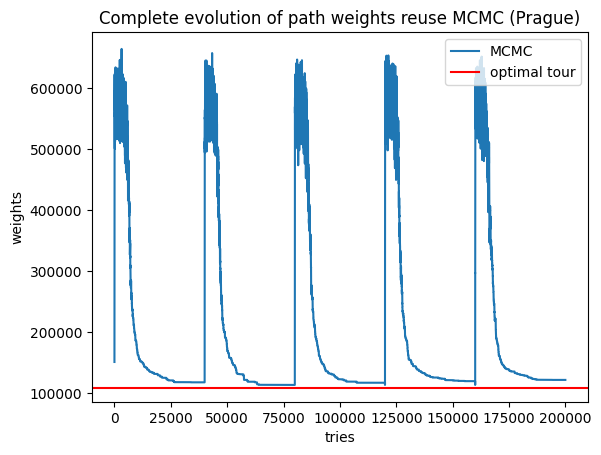

In [25]:
#plt.plot(np.linspace(0, 100004, 100005), weightsBerlin_reuse, label = 'berlin')
plt.plot(np.linspace(0, 200004, 200005), weightsPrague_reuse, label = 'MCMC')
#plt.plot(np.linspace(0, 100004, 100005), weightsLin_reuse, label = 'lin')
plt.xlabel('tries')
plt.ylabel('weights')
plt.title('Complete evolution of path weights reuse MCMC (Prague)')
#plt.yscale('log')
plt.axhline(optWeightPrague, color = 'red', label = 'optimal tour')

plt.legend()
plt.show()

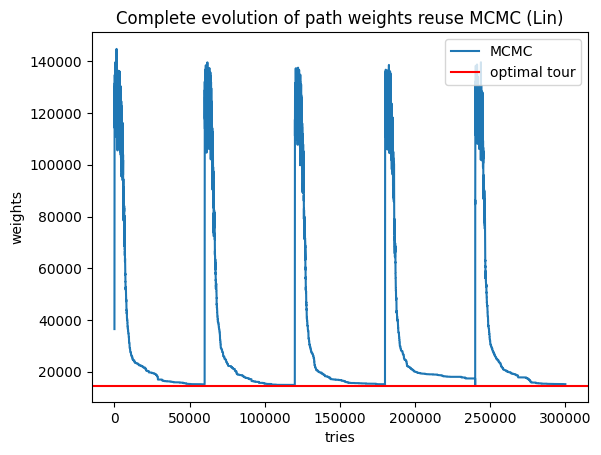

In [21]:
#plt.plot(np.linspace(0, 100004, 100005), weightsBerlin_reuse, label = 'berlin')
#plt.plot(np.linspace(0, 100004, 100005), weightsPrague_reuse, label = 'prague')
plt.plot(np.linspace(0, 300004, 300005), weightsLin_reuse, label = 'MCMC')
plt.xlabel('tries')
plt.ylabel('weights')
plt.title('Complete evolution of path weights reuse MCMC (Lin)')
#plt.yscale('log')
plt.axhline(optWeightLin, color = 'red', label = 'optimal tour')

plt.legend()
plt.show()

In [10]:
weightsPrague2, pathsPrague2, tempsPrague2 = base.traveling_MC_constDist_history_adaptiveTemp(praguePoints, distancesPrague, 40000)
weightsLin2, pathsLin2, tempsLin2 = base.traveling_MC_constDist_history_adaptiveTemp(linPoints, distancesLin, 80000)

In [11]:
bestPathBerlin = pathsBerlin_reuse[np.argmin(weightsBerlin_reuse), :]

berlin_xPosOrdered = np.zeros(52)
berlin_yPosOrdered = np.zeros(52)
berlin_xPosOptOrdered = np.zeros(52)
berlin_yPosOptOrdered = np.zeros(52)

for i in range(len(berlinPoints)):
    berlin_xPosOrdered[i] = berlinCoo[bestPathBerlin[i].astype(int), 1]
    berlin_yPosOrdered[i] = berlinCoo[bestPathBerlin[i].astype(int), 2]
    berlin_xPosOptOrdered[i] = berlinCoo[berlinOptTour[i], 1]
    berlin_yPosOptOrdered[i] = berlinCoo[berlinOptTour[i], 2]

berlin_xPosOptOrdered = np.append(berlin_xPosOptOrdered, berlin_xPosOptOrdered[0])
berlin_yPosOptOrdered = np.append(berlin_yPosOptOrdered, berlin_yPosOptOrdered[0])

########################################################################################################

bestPathPrague = pathsPrague2[np.argmin(weightsPrague2), :]

prague_xPosOrdered = np.zeros(76)
prague_yPosOrdered = np.zeros(76)
prague_xPosOptOrdered = np.zeros(76)
prague_yPosOptOrdered = np.zeros(76)

for i in range(len(praguePoints)):
    prague_xPosOrdered[i] = pragueCoo[bestPathPrague[i].astype(int), 1]
    prague_yPosOrdered[i] = pragueCoo[bestPathPrague[i].astype(int), 2]
    prague_xPosOptOrdered[i] = pragueCoo[pragueOptTour[i], 1]
    prague_yPosOptOrdered[i] = pragueCoo[pragueOptTour[i], 2]

prague_xPosOptOrdered = np.append(prague_xPosOptOrdered, prague_xPosOptOrdered[0])
prague_yPosOptOrdered = np.append(prague_yPosOptOrdered, prague_yPosOptOrdered[0])

#############################################################################################################

bestPathLin = pathsLin2[np.argmin(weightsLin2), :]

lin_xPosOrdered = np.zeros(105)
lin_yPosOrdered = np.zeros(105)
lin_xPosOptOrdered = np.zeros(105)
lin_yPosOptOrdered = np.zeros(105)

for i in range(len(linPoints)):
    lin_xPosOrdered[i] = linCoo[bestPathLin[i].astype(int), 1]
    lin_yPosOrdered[i] = linCoo[bestPathLin[i].astype(int), 2]
    lin_xPosOptOrdered[i] = linCoo[linOptTour[i], 1]
    lin_yPosOptOrdered[i] = linCoo[linOptTour[i], 2]

lin_xPosOptOrdered = np.append(lin_xPosOptOrdered, lin_xPosOptOrdered[0])
lin_yPosOptOrdered = np.append(lin_yPosOptOrdered, lin_yPosOptOrdered[0])

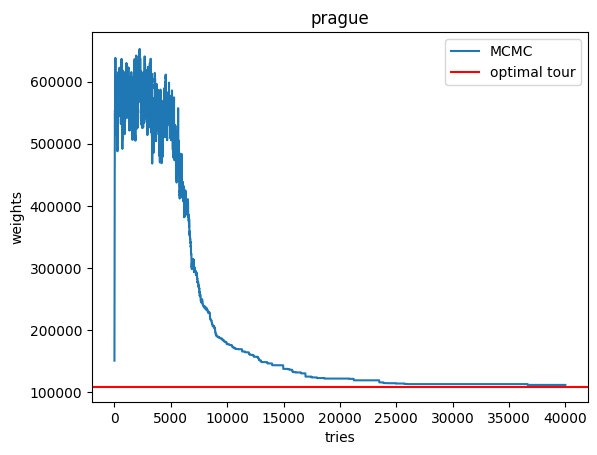

In [26]:
plt.plot(np.linspace(0, 40000, 40001), weightsPrague2, label = 'MCMC')
plt.axhline(optWeightPrague, color = 'red', label = 'optimal tour')
plt.ylabel('weights')
plt.xlabel('tries')
plt.title('prague')


plt.legend()
plt.show()

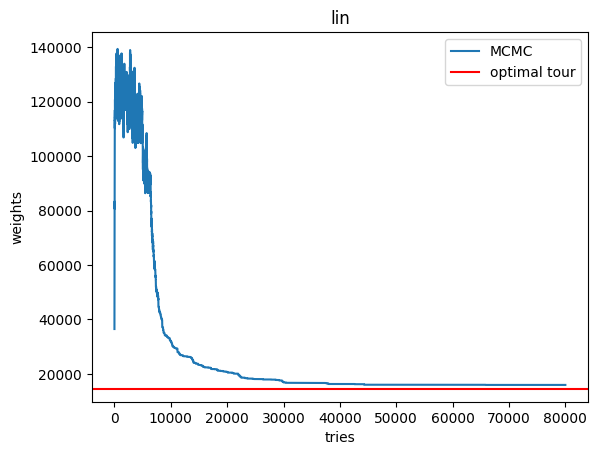

In [27]:
plt.plot(np.linspace(0, 80000, 80001), weightsLin2, label = 'MCMC')
plt.axhline(optWeightLin, color = 'red', label = 'optimal tour')

plt.ylabel('weights')
plt.xlabel('tries')
plt.title('lin')

plt.legend()
plt.show()

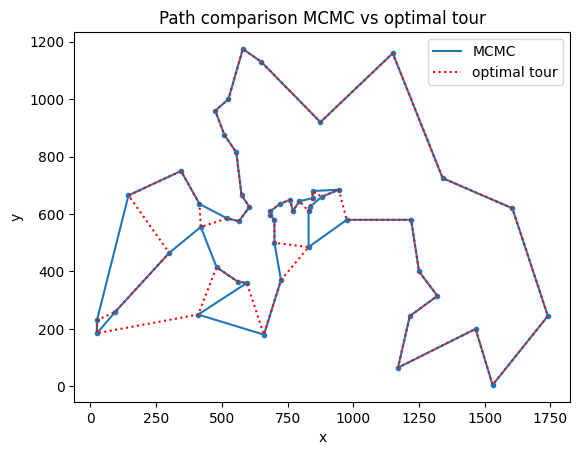

In [28]:
plt.scatter(berlinCoo[:, 1], berlinCoo[:, 2], marker = '.')
plt.plot(np.append(berlin_xPosOrdered, berlin_xPosOrdered[0]), np.append(berlin_yPosOrdered, berlin_yPosOrdered[0]), label = 'MCMC')
plt.plot(berlin_xPosOptOrdered, berlin_yPosOptOrdered, color = 'red', linestyle = 'dotted', label = 'optimal tour')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Path comparison MCMC vs optimal tour')


plt.legend()
plt.show()

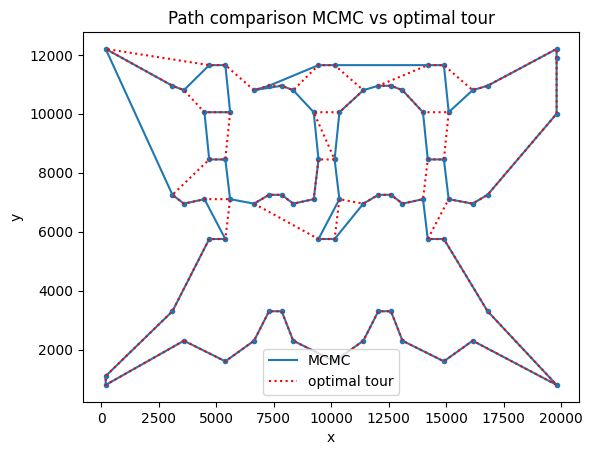

In [29]:
plt.scatter(pragueCoo[:, 1], pragueCoo[:, 2], marker = '.')
plt.plot(np.append(prague_xPosOrdered, prague_xPosOrdered[0]), np.append(prague_yPosOrdered, prague_yPosOrdered[0]), label = 'MCMC')
plt.plot(prague_xPosOptOrdered, prague_yPosOptOrdered, color = 'red', linestyle = 'dotted', label = 'optimal tour')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Path comparison MCMC vs optimal tour')


plt.legend()
plt.show()

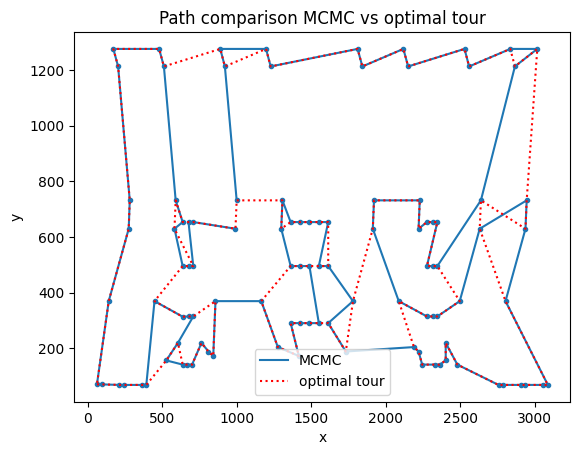

In [30]:
plt.scatter(linCoo[:, 1], linCoo[:, 2], marker = '.')
plt.plot(lin_xPosOrdered, lin_yPosOrdered, label = 'MCMC')
plt.plot(lin_xPosOptOrdered, lin_yPosOptOrdered, color = 'red', linestyle = 'dotted', label = 'optimal tour')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Path comparison MCMC vs optimal tour')


plt.legend()
plt.show()

In [31]:
print('Relative MCMC (reuse + adaptive temp.) performance berlin:', (np.min(weightsBerlin_reuse)-optWeightBerlin)/optWeightBerlin)
print('Relative MCMC (adaptive temp.) performance berlin:', (np.min(weightsBerlin)-optWeightBerlin)/optWeightBerlin)
print('Relative MCMC (reuse + adaptive temp.) performance prague:', (np.min(weightsPrague_reuse)-optWeightPrague)/optWeightPrague)
print('Relative MCMC (adaptive temp.) performance prague:', (np.min(weightsPrague2)-optWeightPrague)/optWeightPrague)
print('Relative MCMC (reuse + adaptive temp.) performance lin:', (np.min(weightsLin_reuse)-optWeightLin)/optWeightLin)
print('Relative MCMC (adaptive temp.) performance lin:', (np.min(weightsLin2)-optWeightLin)/optWeightLin)

Relative MCMC (reuse + adaptive temp.) performance berlin: 0.03898632674279844
Relative MCMC (adaptive temp.) performance berlin: 0.07634097147956209
Relative MCMC (reuse + adaptive temp.) performance prague: 0.04606763704874948
Relative MCMC (adaptive temp.) performance prague: 0.032856721576548134
Relative MCMC (reuse + adaptive temp.) performance lin: 0.03534886297791123
Relative MCMC (adaptive temp.) performance lin: 0.10946344635069583


In [28]:
### 30 runs for adapt. temp. MCMC berlin(40000), pargue(60000) and lin(80000)
berlin_results = np.zeros(100)
prague_results = np.zeros(100)
lin_results = np.zeros(100)

for i in range(100):
    weightsBerlin0503, pathsBerlin0503, tempsBerlin0503 = base.traveling_MC_constDist_history_adaptiveTemp(berlinPoints, distancesBerlin, 40000)
    weightsPrague0503, pathsPrague0503, tempsPrague0503 = base.traveling_MC_constDist_history_adaptiveTemp(praguePoints, distancesPrague, 60000)
    weightsLin0503, pathsLin0503, tempsLin0503 = base.traveling_MC_constDist_history_adaptiveTemp(linPoints, distancesLin, 80000)

    berlin_results[i] = np.min(weightsBerlin0503)
    prague_results[i] = np.min(weightsPrague0503)
    lin_results[i] = np.min(weightsLin0503)



/home/user/Physik_Bonn/CompPhys/project/base.py:243: RuntimeWarning: overflow encountered in exp
  if np.random.uniform(low=0, high=1) < np.exp((pathWeights[i]-new_cost)/temps[i]):


In [29]:
berlin_performance = (berlin_results-optWeightBerlin)/optWeightBerlin
prague_performance = (prague_results-optWeightPrague)/optWeightPrague
lin_performance = (lin_results-optWeightLin)/optWeightLin

In [30]:
lin_performance

array([0.14228513, 0.09738219, 0.13139055, 0.10596091, 0.09108042,
       0.09697832, 0.05656344, 0.06252963, 0.09948745, 0.05259283,
       0.12255087, 0.1503134 , 0.03412172, 0.06212336, 0.11818154,
       0.12396312, 0.10281255, 0.09984624, 0.11455595, 0.15072443,
       0.05355651, 0.08428415, 0.12141849, 0.10642357, 0.09232899,
       0.09390516, 0.10737794, 0.07493738, 0.08787117, 0.12097471,
       0.06917911, 0.08640371, 0.06243324, 0.16138322, 0.12210617,
       0.14491972, 0.07841614, 0.08707506, 0.08538727, 0.13269003,
       0.10432942, 0.14451253, 0.07161454, 0.11887959, 0.10983561,
       0.14247675, 0.12139711, 0.14522283, 0.16183473, 0.09208049,
       0.11651051, 0.04294581, 0.11368593, 0.11419263, 0.05536952,
       0.1124291 , 0.10646457, 0.0978091 , 0.09028699, 0.06214857,
       0.13475819, 0.12946198, 0.06131362, 0.10846369, 0.13454282,
       0.11249318, 0.13228567, 0.05022368, 0.08891432, 0.12600859,
       0.09359279, 0.12797713, 0.11509807, 0.14054605, 0.07759

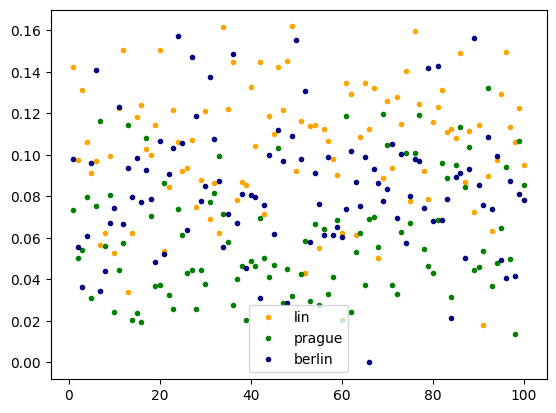

In [32]:
plt.plot(np.linspace(1, 100, 100), lin_performance, linestyle = 'None', marker = '.', color = 'orange', label = 'lin')
plt.plot(np.linspace(1, 100, 100), prague_performance, linestyle = 'None', marker = '.', color = 'green', label = 'prague')
plt.plot(np.linspace(1, 100, 100), berlin_performance, linestyle = 'None', marker = '.', color = 'navy', label = 'berlin')

plt.legend()


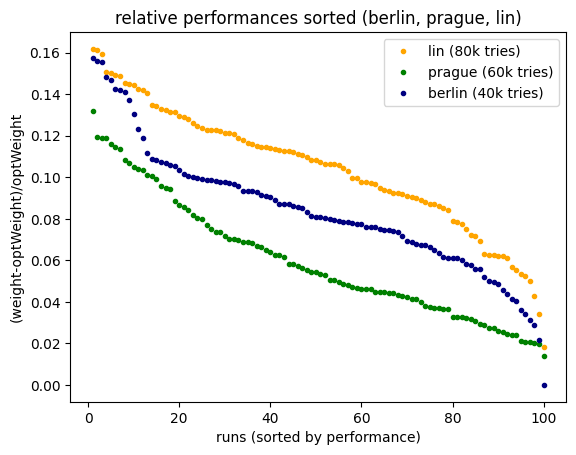

In [33]:
plt.plot(np.linspace(1, 100, 100), np.flip(np.sort(lin_performance)), linestyle = 'None', marker = '.', color = 'orange', label = 'lin (80k tries)')
plt.plot(np.linspace(1, 100, 100), np.flip(np.sort(prague_performance)), linestyle = 'None', marker = '.', color = 'green', label = 'prague (60k tries)')
plt.plot(np.linspace(1, 100, 100), np.flip(np.sort(berlin_performance)), linestyle = 'None', marker = '.', color = 'navy', label = 'berlin (40k tries)')
plt.title('relative performances sorted (berlin, prague, lin)')
plt.xlabel('runs (sorted by performance)')
plt.ylabel('(weight-optWeight)/optWeight')


plt.legend()
plt.show()

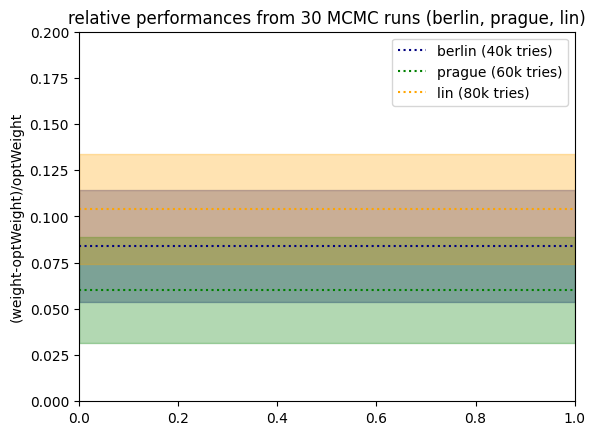

In [34]:
plt.axhline(np.mean(berlin_performance), linestyle = 'dotted', color = 'navy', label = 'berlin (40k tries)')
plt.axhspan(np.mean(berlin_performance)-np.std(berlin_performance), np.mean(berlin_performance)+np.std(berlin_performance), color = 'navy', alpha = 0.3)
plt.axhline(np.mean(prague_performance), linestyle = 'dotted', color = 'green', label = 'prague (60k tries)')
plt.axhspan(np.mean(prague_performance)-np.std(prague_performance), np.mean(prague_performance)+np.std(prague_performance), color = 'green', alpha = 0.3)
plt.axhline(np.mean(lin_performance), linestyle = 'dotted', color = 'orange', label = 'lin (80k tries)')
plt.axhspan(np.mean(lin_performance)-np.std(lin_performance), np.mean(lin_performance)+np.std(lin_performance), color = 'orange', alpha = 0.3)
plt.title('relative performances from 30 MCMC runs (berlin, prague, lin)')
#plt.xlabel()
plt.ylabel('(weight-optWeight)/optWeight')
plt.ylim(0, 0.2)


plt.legend()
plt.show()